<a href="https://colab.research.google.com/github/Pabsgc/Breast-Cancer-ML-predictors/blob/main/RF_breast_cancer_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árbol de Decisión (DT)

Modelo de aprendizaje automático que secciona los datos en áreas llamadas hojas, en base a variables dependientes, según condicionales lógicos.

Cada condicional es un nodo del que parte una rama a otro condicional.

Se utiliza en problemas de Regresión, porque para Clasificación de muchos datos se vuelve muy pesado al necesitar muchísimos condicionales.

Para eso existe el Bosque Aleatorio

# Bosque Aleatorio (RF)

Modelo formado por **Bagging (Boostrap Aggregating)** de Árboles de Decisión.

Sensacional para datasets reducidos con muchas características extraibles a mano.

Utiliza árboles de decisión en paralelo, cada uno tomando decisiones en base a un grupo de características aleatorio. El resultado de la clasificación se da por la votación de la mayoría.

**Trabajan bien con datos sin necesidad de ser escalados**

Voy a probar un modelo RF clasificatorio para cáncer de mama. El set contiene:

- **Número de clases:** 2
- **Datos por clase:** 212(M),357(B)
- **Total:** 569
- **Dimensionalidad:** 30
- **Tipo de datos:** Nº Reales y Positivos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Obtención dataset
from sklearn.datasets import load_breast_cancer
dataset = load_breast_cancer()
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
#Separación datos / etiquetas
X, y = dataset["data"], dataset["target"]
print(X.shape)
print(y.shape)
print(type(X))

(569, 30)
(569,)
<class 'numpy.ndarray'>


In [4]:
#Comprobación de datos, primer paciente
print(X[0])
print(y[0])

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
0


In [5]:
#Aleatorización y seccionamiento del dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
#Se reserva un 10% para validación final, con semilla
print(X_train.shape)
print(X_test.shape)

(512, 30)
(57, 30)


#Tuning de Hiperparámetros

1. El "Ejército" de Árboles

- **n_estimators (100):** Es el número de árboles que tendrá tu bosque. Más árboles suelen dar mejor precisión, pero el entrenamiento será más lento.
- **bootstrap (True):** Si es True, cada árbol se entrena con una muestra aleatoria del dataset (con reemplazo). Es la clave para que los árboles sean distintos entre sí.
- **max_samples (None):** Si usas bootstrap, aquí indicas cuántos datos del total verá cada árbol. Si es None, verá tantos datos como tiene el dataset original (pero muestreados).
- **oob_score (False):** "Out-of-Bag score". Es un truco genial: usa los datos que quedaron fuera del bootstrap de cada árbol para evaluar el modelo mientras entrena, dándote una validación "gratis".

2. Control de Crecimiento (Evitar Overfitting)

- **max_depth (None):** La profundidad máxima del árbol. Si lo dejas en None, el árbol crecerá hasta que todas las hojas sean puras. Cuidado: en datasets pequeños, conviene limitarlo (ej. 5 o 10).
- **min_samples_split (2):** Cuántos datos debe tener un nodo como mínimo para poder dividirse en dos.
- **min_samples_leaf (1):** El número mínimo de datos que debe quedar en una "hoja" (el final de una rama). Aumentarlo suaviza el modelo.
- **max_leaf_nodes (None):** Pone un tope al número total de hojas.
- **ccp_alpha (0):** Se usa para "podar" el árbol después de entrenar (Cost-Complexity Pruning). Ayuda a simplificar árboles demasiado complejos.

3. La Calidad de la División
- **criterion ("gini"):** La función matemática para medir qué tan buena es una división. "Gini" mide la impureza, "entropy" mide el desorden de la información.
- **max_features ("sqrt"):** Cuántas columnas (de tus 30) elige cada árbol al azar para buscar la mejor división. "sqrt" significa que usará $\sqrt{30} \approx 5$ características. Esto hace que el bosque sea diverso.
- **min_impurity_decrease (0):** Un nodo solo se dividirá si la división reduce la impureza más que este valor.
- **min_weight_fraction_leaf (0):** Similar a min_samples_leaf, pero basado en el peso total de las muestras (útil si algunas filas son más "importantes" que otras).

4. Herramientas de Gestión y Reproducebilidad
- **n_jobs (None):** Cuántos núcleos de tu procesador usar. -1 significa "úsalos todos" para ir más rápido.
- **random_state (None):** La semilla aleatoria. Ponle un número (como 42) para que tus resultados sean siempre iguales cada vez que ejecutes el código.
- **class_weight (None):** Muy útil para ti. Si tienes muchos más casos benignos que malignos, puedes decirle al modelo que le dé más importancia a los malignos para compensar, con 'balanced'.
- **verbose (0):** Si quieres que Python te vaya "contando" por consola qué está haciendo mientras entrena.
- **warm_start (False):** Si lo activas, puedes añadir más árboles a un bosque que ya ha sido entrenado anteriormente.
- **monotonic_cst (None):** Obliga a que la predicción siempre suba (o baje) si una característica aumenta. Raro de usar en medicina.

In [20]:
#Creación y primer entrenamiento del modelo Random Forest
#100 árboles, usar todos los núcleos, balancear pesos de etiquetas de set automáticamente, verbose y semilla
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, class_weight='balanced', verbose=0, random_state=42)
rf.fit(X_train, y_train);
#Más adelante se procederá al finetuning con k-folds

In [21]:
#Comprobación de paciente 0
patient=X[0]
print(type(patient))
rf.predict([patient])
#Predice correctamente

<class 'numpy.ndarray'>


array([0])

# Cross Validation (K-folds), cómo elegir :

Si $K$ es muy pequeño (ej. $K=2$): Estás entrenando con solo el 50% de tus datos. El modelo estará sub-entrenado y el error que midas será muy distinto al que tendría el modelo final entrenado con todo el set. Esto introduce **mucho sesgo.**

Si $K$ es muy grande (ej. $K=569$, conocido como Leave-One-Out): Entrenas con casi todos los datos menos uno. Esto es casi perfecto para el entrenamiento, pero los resultados de cada prueba estarán "correlacionados" entre sí. Esto **dispara la varianza** de tu estimación: un solo dato atípico puede hacer que tu métrica salte de forma errática.

Estudios empíricos han demostrado que $K=5$ o $K=10$ proporcionan una estimación del error de generalización que no sufre ni de un sesgo excesivamente alto ni de una varianza muy elevada.

Para este dataset, con $K=5$ Cada "fold" de validación tiene 114 muestras. Esto es lo suficientemente grande para que la métrica (Precisión, Recall, etc.) sea estadísticamente significativa. Si usara $K=20$, cada validación se haría con solo 28 muestras, lo cual es tan poco que **un simple error de clasificación cambiaría tu porcentaje de éxito en un 3.5%**, haciendo que los resultados sean muy ruidosos. Un 0.88% está mejor que 3.5%.

In [22]:
#Cross validated accuracy with 5 folds
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")

array([0.98058252, 0.94174757, 0.96078431, 0.96078431, 0.95098039])

#Matriz de confusión

Muestra alto rendimiento del modelo con los 5 folds gráficamente

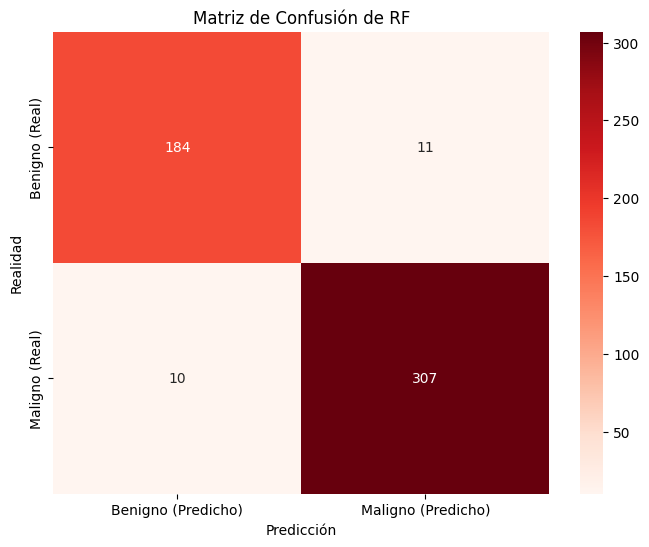

In [32]:
# Matriz de confusión
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(rf, X_train, y_train, cv=5)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, y_train_pred)

import matplotlib.pyplot as plt
import seaborn as sns
# Crear la visualización con seaborn.heatmap. annot muestra número y fmt tipo decimal
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benigno (Predicho)', 'Maligno (Predicho)'],
            yticklabels=['Benigno (Real)', 'Maligno (Real)'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión de RF')
plt.show()

#Precision & Recall

In [33]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train, y_train_pred))
print(recall_score(y_train, y_train_pred))

0.9654088050314465
0.9684542586750788


#F1 Score

In [34]:
from sklearn.metrics import f1_score
f1_score(y_train, y_train_pred)

0.9669291338582677